# MLOps. 2026. Весна.

Преподаватель: Горохов Олег Евгеньевич.

e-mail: gorokhov-oe@cs.msu.ru




# Занятие № 6. Введение в DevOps. Средства оценки и улучшения эффективности программного кода.

## План занятия:


0. DevOps. Напоминание.

1. Тестирование. Виды.

2. Функциональное тестирование. Юнит-тесты. Основные инструменты в Python.

3. Нефункциональное тестирование. Поиск узких мест в коде. Профилирование памяти и времени.

4. Средства увеличения производительности кода.

5. Лабораторная работа.

# 0. DevOps. Напоминание.

Как вам известно, основным элементом MLOps является DevOps - development and operations - это методология, направленная на автоматизацию процессов сборки, настройки и развёртывания программного обеспечения.



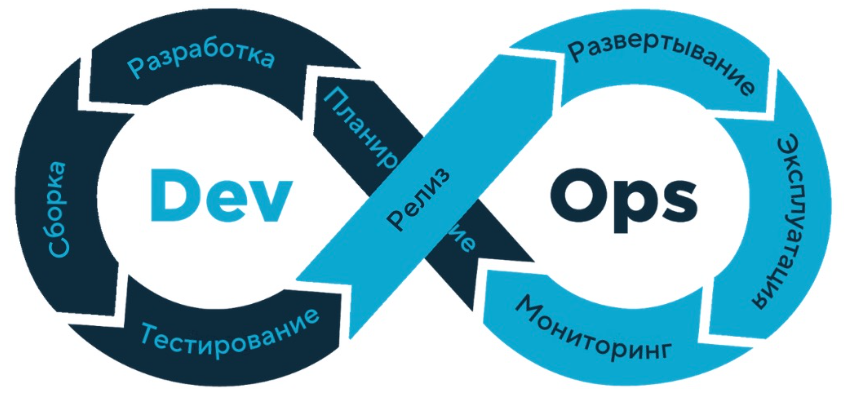

На прошлом занятии мы поговорили про такой важный этап планирования как **проектирование**.

Разработку мы обсудили в прошлом семестре. Про сборку вам рассказывали на 2 курсе. Также про это еще поговорим чуть позже.

Сегодня мы попробуем разобраться с таким важным элементом разработки, как **тестирование**.

# 1. Тестирование. Виды.

**Тестирование программного обеспечения** - исследование программного обеспечения, имеющее своей целью проверку соответствия между действительным поведением программы и её ожидаемым поведением на конечном наборе испытаний (тестов), выбранных определённым образом (ISO/IEC TR 19759:2005).

Простыми словами, в процессе тестирования мы пытаемся оценить соответствие нашего ПО некоторым заявленным требованиям.

Специалисты в области программной инженерии сформулировали основные принципы тестирования. Они представляются в разной форме, представим одну из них:

1. **Тестирование демонстрирует наличие дефектов, но не гарантирует их отсутствие.**
Если мы не обнаружили проблем в ходе тестирования - это не значит на 100%, что их нет. Возможно, мы не рассмотрели какую-то ситуацию.

2. **Исчерпывающее тестирование невозможно.**
Этот принцип сильно проявляется в машинном обучении. При исследовании построенной модели невозможно перебрать все возможные входные данные (поскольку всевозможных комбинаций разного количества признаков вообще говоря, бесконечное количество). Поэтому нужно строить тесты так, чтобы покрыть хотя бы основные **граничные** случаи.

3. **Раннее тестирование.**
Нужно начинать тестирование как можно раньше, чтобы найти и исправить дефекты без необходимости переписывания большого количества кода.

4. **Скопление дефектов.**
Как правило, один дефект может приводить к дефектам в работе ряда функций. Поэтому необходимо проводить регрессивное тестирование, т.е. после устранения ошибки в одной функции, придется заново тестировать все функции, использующие исправленную. Таким образом, нужно иметь возможность автоматизированного тестирования.

5. **Парадокс пестицида.**
Если повторять одни и те же тестовые сценарии снова и снова, часть ошибок может не находиться. Поэтому нужно все время совершенствовать тестирование.

6. **Тестирование зависит от контекста.**
Тестирование проводится по-разному, в зависимости от контекста.
Например, модель, где важен максимально точный ответ, будет тестироваться несколько иначе по сравнению с алгоритмом сбора данных, где важна скорость.

7. **Заблуждение об отсутствии ошибок.**
Отсутствие найденных дефектов при тестировании не всегда означает готовность продукта к релизу. Система должна быть удобна пользователю в использовании и удовлетворять его ожиданиям и потребностям.



## Классификация тестирования по доступу к коду.

В зависимости от доступа тестировщика к коду, выделяют следующие виды тестирования:

1. **Белый (прозрачный) ящик.**
В данном случае нам доступен весь код нашей программы.

2. **Чёрный ящик.**
Нам недоступен код, мы можем только формировать множество входных параметров и анализировать корректность выходных значений.

3. **Серый ящик.**
Композиция первого и второго вида, когда мы имеем доступ только к части программного кода (остальная часть - черный ящик - различные библиотечные функции и классы).

## Классификация по объекту тестирования.

Здесь можно выделить следующие виды тестирования:

1. **Функциональное тестирование.**
Здесь мы оцениваем функциональные качества кода. Т.е. проверяем корректность ответа, который выдаёт наш код для заранее известных входных данных.

2. **Тестирование производительности.**
Оценка потребляемых ресурсов системы: памяти, времени, нагрузки процессора.
Здесь можно выделить **нагрузочное тестирование**, которое оценивает потребляемые ресурсы системы, взяимодействующей с обработкой больших объемов данных и взаимодействием с большим количеством пользователей.

3. **Юзабилити тестирование.**
Проверка эргономичности (т.е. насколько наша система удобна для пользователя).

4. **Тестирование безопасности.**

5. И т.д.

## Классификация по уровню детализации приложения.

1. **Модульное (юнит) тестирование.**
Оценка отдельных логически связных компонент системы (функций, модулей).

2. **Интеграционное тестирование.**
Тестирование, направленное на проверку корректности взаимодействия нескольких модулей, объединенных в единое целое.

3. **Системное тестирование.**
Процесс тестирования системы, на котором проводится не только функциональное тестирование, но и оценка характеристик качества системы — ее устойчивости, надежности, безопасности и производительности.

Вообще, тестирование ПО - это достаточно объемная область, которая изучается отдельно.

Сегодня мы рассмотрим 2 основных аспекта тестирования:

1. Функциональное тестирование.
2. Тестирование производительности.

При чем, для простоты будем рассматривать модульное тестирование, т.е. анализировать заранее известный код.

# 2. Функциональное тестирование. Юнит-тесты. Основные инструменты в Python.

Рассмотрим следующую *задачу*: построить функцию с одним строковым параметром, которая переворачивает строку.

Предложим такое решение:

In [2]:
def reverse(s):
  s=''.join(filter(str.isalnum, s)).lower()
  return s[::-1]

Первым делом посмотрим на нашу функцию, как на черный ящик, т.е. не будем вдаваться в подробности её реализации. И попробуем понять, какие граничные (т.е. проблемные) случаи могут быть:

1. Простой тест на строке, содержащей только маленькие буквы.
2. Тест на строке, содержащей как маленькие, так и большие буквы.
3. Тест на очень маленькой строке (строка - один символ).
4. Тест на очень большой строке (зависит от наших требований).

Попробуем построить словарь истинных входных и выходных данных:

In [3]:
d_input_output = {'hello': 'olleh', 'Aboba': 'abobA', 'a':'a', 'a'*10000: 'a'*10000}

Теперь рассмотрим разные варианты, как можно протестировать нашу функцию.

## Простая проверка

In [4]:
for key, value in d_input_output.items():
  answer = reverse(key)
  if reverse(key)!=value:
    print(key, 'Error! Incorrect answer:', answer)

Aboba Error! Incorrect answer: aboba


## assert

Иногда полезно встраивать проверки прямо в код, выбрасывая некоторое исключение.

Это не позволит нашей программе выполняться дальше в случае ошибки.

Для этого используется конструкция `assert`:

`assert condition, message`

Если условие `condition` неверно, то выбрасывается исключение типа AssertionError с сообщением `message`.

Исправим код:

In [5]:
for key, value in d_input_output.items():
  answer = reverse(key)
  assert answer==value, key + ' Error! Incorrect answer: ' + answer

AssertionError: Aboba Error! Incorrect answer: aboba

## unittest

В Python встроена специальная библиотека unittest, позволяющая проводить модульное тестирование. В этом случае нужно описать класс-тестировщик, позволяющий проверить отдельные граничные ситуации. Отдельный метод данного класса соответствует отдельному тесту.

Построим его:

In [6]:
import unittest

class TestStringMethods(unittest.TestCase):
  def test_1(self):
    self.assertEqual(reverse('hello'), d_input_output['hello'])
  def test_2(self):
    self.assertEqual(reverse('Aboba'), d_input_output['Aboba'])
  def test_3(self):
    self.assertEqual(reverse('a'), d_input_output['a'])
  def test_4(self):
    s = 'a'*10000
    self.assertEqual(reverse(s), d_input_output[s])

Попробуем провести тестирование с помощью данного класса:

In [7]:
unittest.main(argv=[''], verbosity=2, exit=False)

test_1 (__main__.TestStringMethods) ... ok
test_2 (__main__.TestStringMethods) ... FAIL
test_3 (__main__.TestStringMethods) ... ok
test_4 (__main__.TestStringMethods) ... ok

FAIL: test_2 (__main__.TestStringMethods)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/var/folders/fm/gxqm4d_d6nq9_1vl7_58s96w0000gn/T/ipykernel_12010/551780844.py", line 7, in test_2
    self.assertEqual(reverse('Aboba'), d_input_output['Aboba'])
AssertionError: 'aboba' != 'abobA'
- aboba
?     ^
+ abobA
?     ^


----------------------------------------------------------------------
Ran 4 tests in 0.003s

FAILED (failures=1)


Такая библиотека позволяет получать более детальную информацию о тестировании и является более мощным тестом для unit-тестирования.

# 3. Нефункциональное тестирование. Поиск узких мест в коде. Профилирование памяти и времени.

Второй аспект, который важен в процессе оценки ПО - производительность. Ключевым здесь является оценка времени работы и используемой памяти. Для этого применяются специальные средства, которые называются профилировщиками.

Рассмотрим такую задачу: написать функцию, которая будет проверять, является ли заданное число простым.

Предложим решение:

In [8]:
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, n):
        if n % i == 0:
            return False
    return True

Попробуем оценить производительность с помощью существующих средств.

## timeit

Это - магическая команда, которая позволяет оценить среднее время работы программы на серии запусков.

Это может быть полезно, поскольку время работы программы зависит от нагруженности процессора в данный момент, поэтому при разных запусках может получаться разное время работы. При чем, время работы зависит и от входных данных. Поэтому надо рассматривать разные данные и усреднять:

In [9]:
%timeit [is_prime(elem) for elem in [11, 20, 101, 1001]]

3.59 μs ± 6.26 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Обратите внимание, эта команда автоматически выполняет по 100000 запусков для каждого вызова функции.

##line_profiler

Еще одно полезное средство для обнаружения узких мест кода:

In [ ]:
%pip install --quiet line_profiler snakeviz pyinstrument eliot eliot-tree
%load_ext line_profiler

In [ ]:
%lprun -f is_prime is_prime(1000003)

Здесь справа будет выведена построчная сводка с указанием, сколько раз вызывалась каждая строка (Hits), сколько времени ушло на выполнение данной строки (всего, в среднем на каждый вызов, а также процент времени от всего времени).

Данный функционал можно использовать в Colab, как показано выше. При работе с интерпретатором Питона можно использовать альтернативный подход с использованием декораторов. Подробнее - см. в [официальной документации](https://kernprof.readthedocs.io/en/latest/).

По профилированию можно определить так называемые **узкие места** (bottlenecks) - фрагменты кода, вызывающиеся часто и требующие большое количество времени.



Например в данной функции можно видеть, что в цикле происходит очень много итераций (перебираются все числа до $N$). Это можно оптимизировать, перебирая числа до $\sqrt{N}$.

## Профилирование памяти.



Еще один полезные инструмент - библиотека memory_profiler. Она также встроена в Google Colab в виде расширения. Попробуем с ней поработать:

In [ ]:
!pip install memory_profiler

In [ ]:
%load_ext memory_profiler

In [ ]:
def squares_list(n):
    return [i ** 2 for i in range(n)]

In [ ]:
%memit squares_list(1000000)

peak memory: 135.29 MiB, increment: 22.79 MiB


# 4. Средства увеличения производительности кода.

Профилирование позволяет обнаружить узкие места, которые затрачивают много времени на выполнение операций. Следующий этап - это устранение этих узких мест.

Для этого можно использовать разные подходы. Рассмотрим их.

## Использование библиотек NumPy и Pandas.

Библиотека NumPy сильно оптимизирует работу с массивами данных. Библиотека Pandas использует библиотеку NumPy, дополняя ее возможности работой с табличными данными. Поэтому при работе с большими объемами данных лучше использовать эти библиотеки везде, где только можно.

Для примера, рассматрим пример с умножением большого вектора чисел на некоторое число. Также рассмотрим альтернативный способ работы с `timeit`:



In [11]:
import timeit

t1 = timeit.Timer("[elem * 3.14 for elem in range(1000)]")

t2 = timeit.Timer("3.14*np.arange(1000)", setup = 'import numpy as np')

print('List generator:', t1.timeit(number=1000))
print('NumPy:', t2.timeit(number=1000))

List generator: 0.03620279199822107
NumPy: 0.0017943330021807924


Видим, что среднее время работы с генераторами списков на порядок выше, чем при работе с массивами `NumPy`.

## Добавление компиляции. JIT-компиляция.

Как вы знаете, Python - интерпретируемый язык. Этот код выполняется построчно, что позволяет взаимодействовать с программой в процессе разработки.

Но в этом случае мы получаем значительные накладные расходы.

Чтобы их устранить, можно использовать 2 подхода:

1. Использование интерпретатора [CPython](https://ru.wikipedia.org/wiki/CPython), который является модификацией Python, оптимизирующей выполнение программ. Этот интерпретатор написан на Си и позволяет проводить компиляцию в байт-код. Однако, для корректной работы с данным интерпретатором придется переписывать часть функций, делая их менее понятными.

2. Использование JIT-компиляции (Just In Time). Этот вид компиляции используется в Java-подобных языках, позволяя строить байт-код "на ходу", для каждой отдельной строчки.

Рассмотрим второй подход. Он реализуется с помощью специальной библиотеки Numba, которая позволяет сильно оптимизировать выполнение кода.

In [12]:
!pip install numba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 8.3 MB/s eta 0:00:00a 0:00:01


In [13]:
from numba import jit
import numpy as np # Используется для оптимизации

# Функция без оптимизации
def sum_array_noopt(arr):
  result = 0
  for i in arr:
    result += i
  return result

# Функция с оптимизацией
@jit(nopython=True)
def sum_array_opt(arr):
  result = 0
  for i in arr:
    result += i
  return result

# Функция с оптимизацией и кешированием
@jit(nopython=True, cache=True)
def sum_array_opt_cache(arr):
  result = 0
  for i in arr:
    result += i
  return result

Оценим время работы функции:

In [14]:
from datetime import datetime

large_array = np.arange(1000000)
t1=datetime.now()
sum_array_noopt(large_array)
t2 = datetime.now()
sum_array_opt(large_array)
t3 = datetime.now()
sum_array_opt_cache(large_array)
t4 = datetime.now()

print('No opt time:', t2-t1)
print('Opt time:', t3-t2)
print('Opt time with cache:', t4-t3)

No opt time: 0:00:00.048962
Opt time: 0:00:01.192960
Opt time with cache: 0:00:00.034328


Видим, что JIT-компиляция позволяет сильно улучшить производительность, а добавление кэша позволяет получить дополнительное ускорение.

## Оптимизация памяти. Использование генераторов.

Вернёмся к коду с генерацией квадратов целых чисел и попробуем заменить код на генератор:

In [15]:
def squares_list(n):
  lst = []
  for i in range(n):
    lst.append(i**2)
  return lst

def squares_list_gen_1(n):
  for i in range(n):
    yield i**2

def squares_list_gen_2(n):
  return (i ** 2 for i in range(n))

In [17]:
%memit squares_list(1000000)

UsageError: Line magic function `%memit` not found.


In [ ]:
%memit squares_list_gen_1(1000000)

peak memory: 248.01 MiB, increment: 0.00 MiB


In [ ]:
%memit squares_list_gen_2(1000000)

peak memory: 248.01 MiB, increment: 0.00 MiB


Альтернативный вариант:

In [ ]:
# Создадим файл с профилируемой функцией
%%file mprun_demo.py
@profile
def squares_list(n):
  lst = []
  for i in range(n):
    lst.append(i**2)
  return lst

if __name__=='__main__':
  squares_list(10000)

Writing mprun_demo.py


In [ ]:
!python -m memory_profiler mprun_demo.py

Filename: mprun_demo.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     1   42.297 MiB   42.297 MiB           1   @profile
     2                                         def squares_list(n):
     3   42.297 MiB    0.000 MiB           1     lst = []
     4   42.684 MiB    0.301 MiB       10001     for i in range(n):
     5   42.684 MiB    0.086 MiB       10000       lst.append(i**2)
     6   42.684 MiB    0.000 MiB           1     return lst




# 5. Лабораторная работа.

Рассмотрим задачу бинарной классификации новостных статей.

Дан набор данных новостных статей с указанием тематики (мы рассмотрим только 2 темы):

In [25]:
from sklearn import datasets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import sklearn
import numpy as np

newsgroups = datasets.fetch_20newsgroups(
                    subset='all',
                    categories=['alt.atheism', 'sci.space']
             )

Теперь рассмотрим простой алгоритм классификации текстов и оценки качества:

In [26]:
X = newsgroups.data
y = newsgroups.target

In [27]:
# Обработка текстовых данных
def preprocess_one_text(txt):
  return txt.lower()

def preprocess(texts):
  return [preprocess_one_text(txt) for txt in texts]

In [28]:
X_preprocessed = preprocess(X)

In [29]:
# Получение тренировочной и тестовой выборок:

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3)

In [30]:
# Векторизация - рассмотрим TF-IDF
vectorizer = TfidfVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [31]:
# Строим предсказания и оцениваем качество

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression().fit(X_train_vectorized, y_train)
preds = clf.predict(X_test_vectorized)

accuracy_score(preds, y_test)

0.9944029850746269

В рамках данного задания необходимо выполнить следующие этапы:

1. Проведение unit-тестирование для функций обработка данных - любым из рассмотренных способов.

2. Оценка производительности (памяти и времени) для алгоритма векторизации и итогового алгоритма классификации.

3. Предложение своих способов оптимизации работы алгоритмов (использование более детальной обработки и уменьшение размера словаря за счёт очистки данных, использование снижения размерности - PCA, NMF). Исследование качества итогового алгоритма, времени работы и требуемой памяти для предложенных подходов.

Дополнительно (за доп. баллы) можно рассмотреть следующее:

1. Исследовать (построить график) зависимость времени и требуемой памяти для разного количества компонент в методах снижения размерности.

2. Исследование зависимости качества и производительности итогового решения от разного числа компонент в методах снижения размерности.

3. Исследование качества работы и производительности с применением разных способов векторизации (например, эмбеддинги).

## 1. Проведение unit-тестирования для функций обработки данных

In [32]:
import unittest


class TestPreprocessLower(unittest.TestCase):

    def test_basic_lowercase(self):
        self.assertEqual(preprocess_one_text("HELLO"), "hello")
        self.assertEqual(preprocess_one_text("TeSt"), "test")

    def test_already_lowercase(self):
        self.assertEqual(preprocess_one_text("hello"), "hello")

    def test_mixed_case_sentence(self):
        self.assertEqual(
            preprocess_one_text("Hello World From NASA"),
            "hello world from nasa"
        )

    def test_empty_string(self):
        self.assertEqual(preprocess_one_text(""), "")

    def test_spaces_preserved(self):
        self.assertEqual(
            preprocess_one_text("  HELLO   WORLD  "),
            "  hello   world  "
        )

    def test_numbers_and_symbols(self):
        self.assertEqual(
            preprocess_one_text("NASA-2024!!!"),
            "nasa-2024!!!"
        )

    def test_long_string(self):
        s = "A" * 10000
        self.assertEqual(preprocess_one_text(s), s.lower())

suite = unittest.TestLoader().loadTestsFromTestCase(TestPreprocessLower)
unittest.TextTestRunner(verbosity=2).run(suite)

test_already_lowercase (__main__.TestPreprocessLower) ... ok
test_basic_lowercase (__main__.TestPreprocessLower) ... ok
test_empty_string (__main__.TestPreprocessLower) ... ok
test_long_string (__main__.TestPreprocessLower) ... ok
test_mixed_case_sentence (__main__.TestPreprocessLower) ... ok
test_numbers_and_symbols (__main__.TestPreprocessLower) ... ok
test_spaces_preserved (__main__.TestPreprocessLower) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.004s

OK


<unittest.runner.TextTestResult run=7 errors=0 failures=0>

## 2. Оценка производительности алгоритма векторизации и итоговой классификации

In [35]:
import timeit
import tracemalloc


def peak_mib(f):
    tracemalloc.start()
    f()
    _, p = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return p / (1024 * 1024)


t = timeit.Timer(lambda: TfidfVectorizer().fit_transform(X_train))
print("TF-IDF fit_transform train:", t.timeit(number=3) / 3)

v_lab = TfidfVectorizer()
v_lab.fit(X_train)
t = timeit.Timer(lambda: v_lab.transform(X_test))
print("TF-IDF transform test:", t.timeit(number=10) / 10)

t = timeit.Timer(lambda: LogisticRegression(max_iter=2000).fit(X_train_vectorized, y_train))
print("LogReg fit:", t.timeit(number=5) / 5)

t = timeit.Timer(lambda: clf.predict(X_test_vectorized))
print("LogReg predict:", t.timeit(number=20) / 20)


def _only_tfidf_train():
    TfidfVectorizer().fit_transform(X_train)


def _tfidf_then_clf():
    tv = TfidfVectorizer()
    Xt = tv.fit_transform(X_train)
    Xe = tv.transform(X_test)
    c = LogisticRegression(max_iter=2000).fit(Xt, y_train)
    c.predict(Xe)


print("tracemalloc peak MiB, only tfidf train:", peak_mib(_only_tfidf_train))
print("tracemalloc peak MiB, tfidf+clf:", peak_mib(_tfidf_then_clf))


TF-IDF fit_transform train: 0.16497534733449962
TF-IDF transform test: 0.061355104199901686
LogReg fit: 0.01822834179911297
LogReg predict: 0.0001575895497808233
tracemalloc peak MiB, only tfidf train: 10.177690505981445
tracemalloc peak MiB, tfidf+clf: 14.504804611206055


## 3. Оптимизация и сравнение (словарь, SVD, NMF)


In [40]:
import timeit
import tracemalloc

from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics import accuracy_score


def peak_mib(f):
    tracemalloc.start()
    f()
    _, p = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return p / (1024 * 1024)


acc0 = accuracy_score(y_test, clf.predict(X_test_vectorized))

tv = TfidfVectorizer(max_features=8000, min_df=2, max_df=0.95)
Xtr = tv.fit_transform(X_train)
Xte = tv.transform(X_test)
c = LogisticRegression(max_iter=2000).fit(Xtr, y_train)
acc1 = accuracy_score(y_test, c.predict(Xte))

svd = TruncatedSVD(n_components=80, random_state=0)
Ztr = svd.fit_transform(Xtr)
Zte = svd.transform(Xte)
c2 = LogisticRegression(max_iter=2000).fit(Ztr, y_train)
acc2 = accuracy_score(y_test, c2.predict(Zte))

nmf = NMF(n_components=50, random_state=0, max_iter=200)
Wtr = nmf.fit_transform(Xtr)
Wte = nmf.transform(Xte)
c3 = LogisticRegression(max_iter=2000).fit(Wtr, y_train)
acc3 = accuracy_score(y_test, c3.predict(Wte))

print("acc baseline", acc0)
print("acc tf-idf", acc1)
print("acc + SVD 80", acc2)
print("acc + NMF 50", acc3)

t = timeit.Timer(lambda: TfidfVectorizer(max_features=8000, min_df=2, max_df=0.95).fit_transform(X_train))
print("time tfidf opt", t.timeit(number=3) / 3)
t = timeit.Timer(lambda: TruncatedSVD(n_components=80, random_state=0).fit_transform(Xtr))
print("time svd", t.timeit(number=5) / 5)
t = timeit.Timer(lambda: NMF(n_components=50, random_state=0, max_iter=200).fit_transform(Xtr))
print("time nmf", t.timeit(number=3) / 3)


def run_restricted_vocab_tfidf_logreg_predict():
    tv2 = TfidfVectorizer(max_features=8000, min_df=2, max_df=0.95)
    a = tv2.fit_transform(X_train)
    b = tv2.transform(X_test)
    LogisticRegression(max_iter=2000).fit(a, y_train).predict(b)


print(
    "tracemalloc peak MiB: tfidf, logreg, predict:",
    peak_mib(run_restricted_vocab_tfidf_logreg_predict),
)


acc baseline 0.9944029850746269
acc tf-idf 0.996268656716418
acc + SVD 80 0.9906716417910447
acc + NMF 50 0.9309701492537313
time tfidf opt 0.168758069332398
time svd 0.15914015839953208
time nmf 3.7736933333314178
tracemalloc peak MiB: tfidf, logreg, predict: 10.1564302444458
